In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../../data/raw'
OUT = '../../data/processed/combined_hourly_regional.csv'
os.makedirs(os.path.dirname(OUT), exist_ok=True)

STATIONS   = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']

WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]

CONTINUOUS = ['load_mw', 'gas_price_mmbtu'] + WEATHER_COLS

### 1. Load & align datetimes

In [39]:
def load(path, dt_col='datetime'):
    df = pd.read_csv(path)
    raw = df[dt_col].astype(str)
    if raw.str.contains(r'[+-]\d{2}:\d{2}$', regex=True).any():
        dt = pd.to_datetime(raw, utc=True).dt.tz_convert('America/Los_Angeles').dt.tz_localize(None)
    else:
        dt = pd.to_datetime(raw)
    df[dt_col] = dt
    return df.set_index(dt_col).sort_index()

caiso   = load(f'{RAW}/caiso_hourly.csv')
weather = load(f'{RAW}/weather_hourly_regional.csv')
econ    = load(f'{RAW}/economic_hourly.csv')

In [40]:
df = caiso.join(weather, how='inner').join(econ, how='inner')

In [41]:
missing = df.isnull().mean() * 100

In [42]:
df[CONTINUOUS] = df[CONTINUOUS].interpolate(method='time', limit=6)
df[CONTINUOUS] = df[CONTINUOUS].ffill()

for col in CONTINUOUS:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

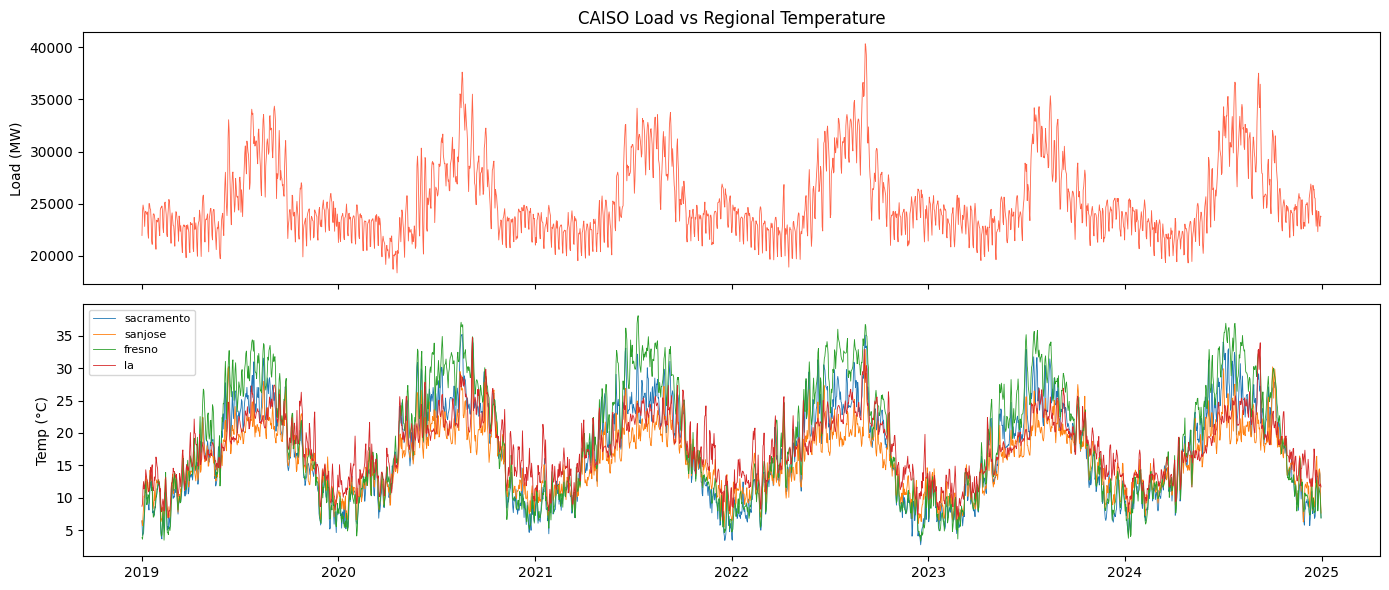

In [43]:
temp_cols = [f'{s}_temperature_c' for s in STATIONS]
daily = df[['load_mw'] + temp_cols].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(daily.index, daily['load_mw'], linewidth=0.6, color='tomato')
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('CAISO Load vs Regional Temperature')

for col in temp_cols:
    axes[1].plot(daily.index, daily[col], linewidth=0.6, label=col.replace('_temperature_c', ''))
axes[1].set_ylabel('Temp (°C)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

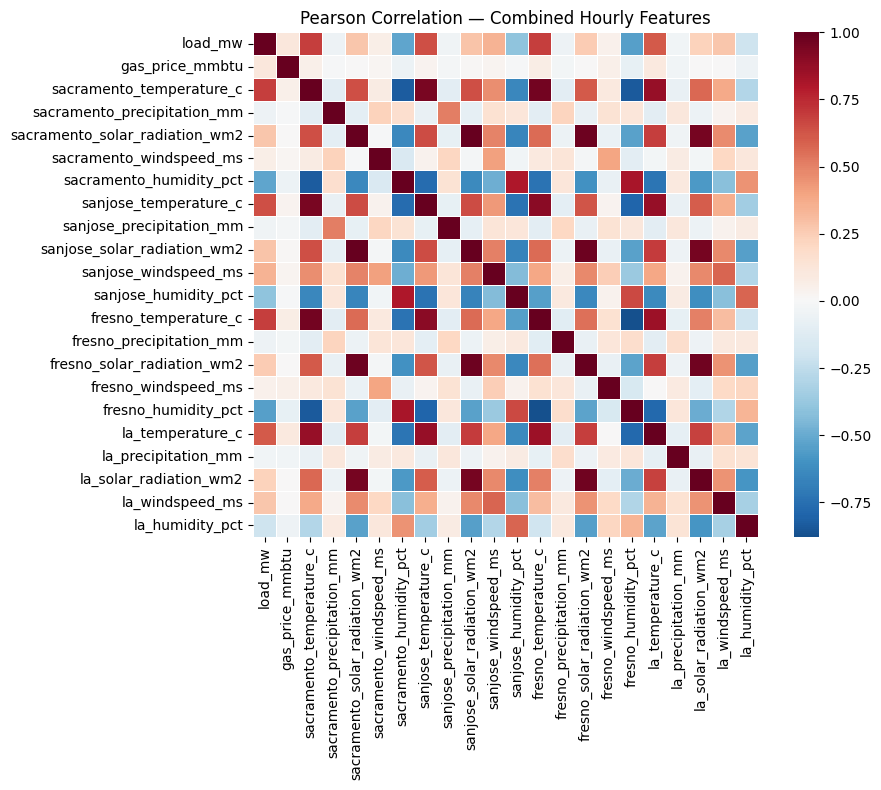

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[CONTINUOUS].corr(),
    annot=False, cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, ax=ax
)
ax.set_title('Pearson Correlation — Combined Hourly Features')
plt.tight_layout()
plt.savefig('../../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

In [45]:
df.to_csv(OUT)